In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Configuration

In [36]:
FEATURE_COLS = [
    "cpuUsage",
    "ramUsage",
    "networkConnections",
    "processCount",
    "cpuPackagePower",
    "cpuAverageClock",
    "cpuTemperature"
]

TEMP_COL = "cpuTemperature"

LOOKBACK = 20

In [37]:
print(type(FEATURE_COLS))
print(FEATURE_COLS)
print("Number of features:", len(FEATURE_COLS))

<class 'list'>
['cpuUsage', 'ramUsage', 'networkConnections', 'processCount', 'cpuPackagePower', 'cpuAverageClock', 'cpuTemperature']
Number of features: 7


# 2. Load Data

In [ ]:
train_df = pd.read_csv('prabhsimrat_logs.csv')
test_df = pd.read_csv('sushant_logs.csv')


# 3. Clean Data

In [39]:
def clean_data(df):
    df = df.copy()
    required_cols = list(set(FEATURE_COLS))
    df = df.dropna(subset= required_cols)
    df = df.reset_index(drop = True)
    return df

In [40]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

# 4. Split Training Laptop Chronologically

In [41]:
train_end = int(len(train_df)*0.7)
val_end = int(len(train_df)*0.85)

df_train = train_df.iloc[:train_end].copy()
df_val = train_df.iloc[:val_end].copy()

# Remaining 15% can be used as same-device test data

df_same_device_test = train_df.iloc[val_end].copy()


# 5. Fit Scaler only on Traininig Data

In [42]:
scaler_X = StandardScaler()
scaler_X.fit(df_train[FEATURE_COLS])


StandardScaler()

# 6. Create Sequences

In [43]:
def create_sequences(df, scaler, lookback):

    # Safety check
    if not isinstance(FEATURE_COLS, list):
        raise TypeError(
            f"FEATURE_COLS must be a list, "
            f"but got {type(FEATURE_COLS)}"
        )

    if len(df) <= lookback:
        raise ValueError(
            f"Dataset has only {len(df)} rows, "
            f"but LOOKBACK is {lookback}. "
            f"You need more than {lookback} rows."
        )

    # Always force a 2D DataFrame
    feature_data = df.loc[:, FEATURE_COLS].copy()

    scaled_features = scaler.transform(feature_data)

    temperatures = df[TEMP_COL].to_numpy()

    X = []
    y_delta = []
    current_temps = []
    actual_future_temps = []

    for i in range(lookback, len(df)):

        sequence = scaled_features[i - lookback:i]

        current_temp = temperatures[i - 1]
        future_temp = temperatures[i]

        delta_temp = future_temp - current_temp

        X.append(sequence)
        y_delta.append(delta_temp)
        current_temps.append(current_temp)
        actual_future_temps.append(future_temp)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y_delta, dtype=np.float32),
        np.asarray(current_temps, dtype=np.float32),
        np.asarray(actual_future_temps, dtype=np.float32)
    )

In [44]:
X_train, y_train, _, _ = create_sequences(df_train, scaler_X, LOOKBACK)
X_val, y_val , _, _ = create_sequences(df_val, scaler_X, LOOKBACK)

# 7. Build Model

In [45]:
from tensorflow.keras.layers import Input

model = Sequential([

    Input(
        shape=(LOOKBACK, len(FEATURE_COLS))
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 20, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

# 8. Callbacks

In [46]:
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 8, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience=4, min_lr = 1e-6)


# 9. Train Model

In [47]:
history = model.fit(
    X_train, y_train, validation_data = (X_val, y_val), epochs = 100, batch_size = 32, callbacks=[early_stopping, reduce_lr], shuffle = False
)

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 18.5081 - mae: 1.9211 - val_loss: 21.4741 - val_mae: 1.9319 - learning_rate: 0.0010
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - loss: 18.3033 - mae: 1.9495 - val_loss: 21.3121 - val_mae: 1.8398 - learning_rate: 0.0010
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 18.1657 - mae: 1.9343 - val_loss: 21.0729 - val_mae: 1.8485 - learning_rate: 0.0010
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 17.9536 - mae: 1.9306 - val_loss: 20.8466 - val_mae: 1.9751 - learning_rate: 0.0010
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 17.6498 - mae: 1.9195 - val_loss: 20.2314 - val_mae: 1.8729 - learning_rate: 0.0010
Epoch 6/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 17.1000 - mae: 1.9078 - val_loss: 19.4690 - val_mae: 1.8707 - learning_rate: 0.0010
Epoch 7/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 16.6099 - mae: 1.8905 - val_loss: 18.7834 - val_mae: 1.

# Saving the Model

In [48]:
import joblib
import json

# 1. Save trained model
model.save("cpu_temperature_delta_model.keras")

# 2. Save fitted scaler
joblib.dump(
    scaler_X,
    "cpu_feature_scaler.pkl"
)

# 3. Save model configuration
config = {
    "feature_cols": FEATURE_COLS,
    "temp_col": TEMP_COL,
    "lookback": LOOKBACK
}

with open("model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("=================================")
print("Everything saved successfully!")
print("=================================")
print("Model:  cpu_temperature_delta_model.keras")
print("Scaler: cpu_feature_scaler.pkl")
print("Config: model_config.json")

Everything saved successfully!
Model:  cpu_temperature_delta_model.keras
Scaler: cpu_feature_scaler.pkl
Config: model_config.json


# 10. Evaluation Function

In [49]:
def evaluate_model(model, df, scaler, name):

    X, _, current_temps, actual_temps = create_sequences(
        df,
        scaler,
        LOOKBACK
    )

    predicted_delta = model.predict(X).flatten()

    # Reconstruct actual temperature
    predicted_temps = (
        current_temps + predicted_delta
    )

    mae = mean_absolute_error(
        actual_temps,
        predicted_temps
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_temps,
            predicted_temps
        )
    )

    r2 = r2_score(
        actual_temps,
        predicted_temps
    )

    print(f"\n===== {name} =====")

    print(f"MAE:  {mae:.2f} °C")
    print(f"RMSE: {rmse:.2f} °C")
    print(f"R²:   {r2:.4f}")


    plt.figure(figsize=(14, 6))

    plt.plot(
        actual_temps[:200],
        label="Actual Temperature"
    )

    plt.plot(
        predicted_temps[:200],
        "--",
        label="Predicted Temperature"
    )

    plt.title(name)

    plt.xlabel("Time Steps")
    plt.ylabel("Temperature (°C)")

    plt.legend()
    plt.grid(True)

    plt.show()


# 11. Same Laptop Test

In [54]:
print("Original train_df:", train_df.shape)
print("df_train:", df_train.shape)
print("df_val:", df_val.shape)
print("df_same_device_test:", df_same_device_test.shape)

print("\nTotal rows after split:")
print(
    len(df_train)
    + len(df_val)
    + len(df_same_device_test)
)

Original train_df: (16361, 8)
df_train: (11452, 8)
df_val: (2454, 8)
df_same_device_test: (2455, 8)

Total rows after split:
16361


In [53]:
# ============================================================
# RECREATE THE SPLIT CORRECTLY
# ============================================================

train_end = int(len(train_df) * 0.70)
val_end = int(len(train_df) * 0.85)

df_train = train_df.iloc[:train_end].copy()

df_val = train_df.iloc[
    train_end:val_end
].copy()

df_same_device_test = train_df.iloc[
    val_end:
].copy()


# Verify
print("Original train_df:", train_df.shape)
print("df_train:", df_train.shape)
print("df_val:", df_val.shape)
print("df_same_device_test:", df_same_device_test.shape)

total = (
    len(df_train)
    + len(df_val)
    + len(df_same_device_test)
)

print("\nTotal rows after split:", total)

assert total == len(train_df), "Split sizes do not match!"
assert isinstance(df_same_device_test, pd.DataFrame)

Original train_df: (16361, 8)
df_train: (11452, 8)
df_val: (2454, 8)
df_same_device_test: (2455, 8)

Total rows after split: 16361


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

===== Same Laptop Test =====
MAE:  1.91 °C
RMSE: 5.32 °C
R²:   0.7906


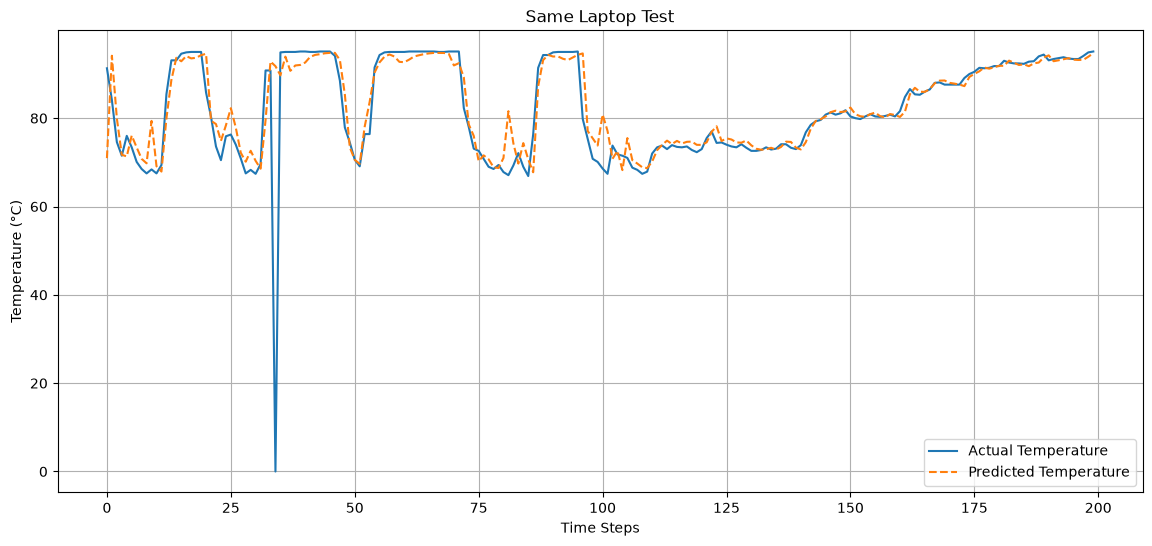

In [55]:
evaluate_model(
    model,
    df_same_device_test,
    scaler_X,
    "Same Laptop Test"
)

# 12. Different Laptop Test

503/503 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

===== Unseen Laptop Test (Sushant) =====
MAE:  3.00 °C
RMSE: 4.92 °C
R²:   0.8601


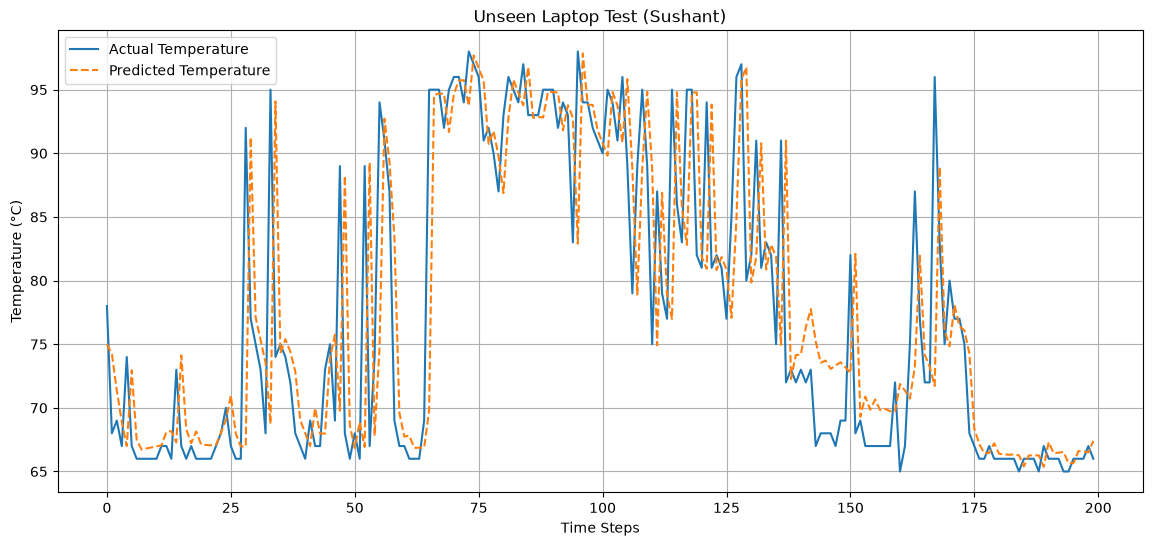

In [58]:
evaluate_model(
    model,
    test_df,
    scaler_X,
    "Unseen Laptop Test (Sushant)"
)

Testing on Manan Logs

In [56]:
test_df_manan = pd.read_csv('manan_logs.csv')

632/632 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

===== Unseen Laptop Test (Manan) =====
MAE:  1.70 °C
RMSE: 2.84 °C
R²:   0.9449


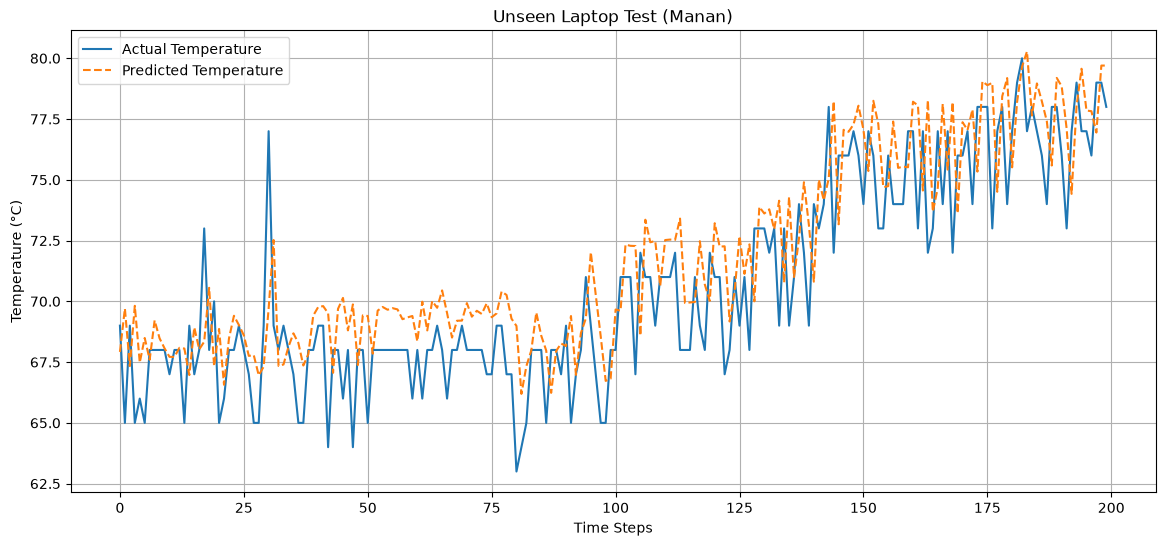

In [59]:
evaluate_model(
    model,
    test_df_manan,
    scaler_X,
    "Unseen Laptop Test (Manan)"
)